In [1]:
import pandas as pd

In [3]:
customers=pd.read_csv('../Datos/Originales/Datos_look&like/customers_data_2.csv',sep=';')
items=pd.read_csv('../Datos/Originales/Datos_look&like/items_data.csv')
lyl=pd.read_csv('../Datos/Originales/Datos_look&like/look_and_like_data_2.csv',sep=';')



In [4]:
import pandas as pd
import numpy as np

# Función auxiliar para analizar un DataFrame individual
def check_quality(df, name):
    print(f"\n{'='*20} ANÁLISIS: {name} {'='*20}")
    print(f"Dimensiones: {df.shape}")
    
    # 1. Análisis de Nulos
    nulos = df.isnull().sum()
    nulos_pct = (nulos / len(df)) * 100
    nulos_df = pd.DataFrame({'Total Nulos': nulos, '% Nulos': nulos_pct})
    # Filtramos para mostrar solo columnas con problemas o todas si prefieres
    print("\n--- Valores Nulos ---")
    if nulos.sum() == 0:
        print("¡No hay valores nulos!")
    else:
        print(nulos_df[nulos_df['Total Nulos'] > 0])
    
    # 2. Tipos de datos (Para ver si los IDs son int, float o object)
    print("\n--- Tipos de Datos (Head) ---")
    print(df.dtypes)
    
    # 3. Duplicados
    duplicados = df.duplicated().sum()
    print(f"\n--- Filas totalmente duplicadas: {duplicados} ---")

# Ejecutamos el análisis individual
check_quality(customers, "CUSTOMERS")
check_quality(items, "ITEMS")
check_quality(lyl, "LOOK & LIKE")

print(f"\n{'='*20} VERIFICACIÓN DE CLAVES (CRUCIAL PARA MERGE) {'='*20}")

# 4. Comprobar consistencia de IDs (Integridad Referencial)
# ¿Cuántos usuarios de lyl NO están en customers?
missing_users = lyl[~lyl['user_id'].isin(customers['user_id'])]['user_id'].nunique()
total_users_lyl = lyl['user_id'].nunique()
print(f"Usuarios en 'lyl' que NO existen en 'customers': {missing_users} de {total_users_lyl}")

# ¿Cuántos productos de lyl NO están en items?
missing_items = lyl[~lyl['product_variant_id'].isin(items['product_variant_id'])]['product_variant_id'].nunique()
total_items_lyl = lyl['product_variant_id'].nunique()
print(f"Productos en 'lyl' que NO existen en 'items': {missing_items} de {total_items_lyl}")



==================== ANÁLISIS: CUSTOMERS ====================
Dimensiones: (387, 26)

--- Valores Nulos ---
               Total Nulos    % Nulos
fit_top                  1   0.258398
fit_bottom               1   0.258398
size_footwear            6   1.550388
size_bra                23   5.943152
size_cup                33   8.527132
weight                   1   0.258398
adventurous              2   0.516796
prices                   2   0.516796
job                      2   0.516796
date_birth               3   0.775194
age                      3   0.775194
is_mother               20   5.167959
style_1                  1   0.258398
style_2                 49  12.661499

--- Tipos de Datos (Head) ---
user_id                   object
user_market               object
frequency                 object
newsletter_subscribed      int64
dress_leisure             object
dress_work                object
fit_top                   object
fit_bottom                object
body_shape                

In [5]:
cols_to_drop = [
    'back_neckline', 'basic', 'chest_volume', 'composition_detail', 
    'cover', 'elasticated_lining', 'hips_volume', 'leg_height',
    'light', 'neck', 'neckline', 'long_cm', 'shoulders_pad', 
    'size_feature', 'sleeve_long', 'sole_length', 'thicknees', 'bottom', 'size_cup', 'date_birth', 
     'season', 'cut', 'finishing','heel_length']

items = items.drop(columns=cols_to_drop, errors='ignore')


In [6]:

lyl_customers = pd.merge(lyl, customers, on='user_id', how='left')

df_final = pd.merge(lyl_customers, items, on='product_variant_id', how='left')



In [7]:
cols_to_drop = ['product_variant_id', 'user_id']

df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

df=df_final
df2=df_final
df_final


,response,place,occurred_on_,user_market,frequency,newsletter_subscribed,dress_leisure,dress_work,fit_top,fit_bottom,...,shot,sizing,sleeve,sleeve_long_cm,style,toecap,type_of_length,waist_contour,weather,current_price_eur
0,True,look-and-like,2025-01-26 11:17:28.849743,FR,on-demand,0,street,femenine,straight,straight,...,short,small,NaN,NaN,"casual,street",NaN,long,39.0,"cold,cold_season",10995.0
1,False,look-and-like,2025-01-19 09:44:08.914438,FR,bimonthly,0,street,street,loose,straight,...,NaN,NaN,NaN,NaN,"boho,street",NaN,NaN,NaN,"cold_season,warm_season",3790.0
2,True,look-and-like,2025-01-01 08:28:42.628929,FR,on-demand,0,classic,street,loose,loose,...,NaN,normal,"cuffed_sleeve,down_shoulders",61.0,"casual,classic",NaN,NaN,47.0,"cold,cold_season",3999.0
3,False,checkout-welcome,2025-01-01 10:10:41.000233,FR,on-demand,0,street,femenine,fitted,fitted,...,NaN,normal,puffed_sleeve,64.0,"boho,street",NaN,NaN,54.0,cold,2999.0
4,False,look-and-like,2025-01-07 10:56:10.280325,FR,on-demand,0,femenine,classic,loose,straight,...,NaN,normal,tulip_sleeve,5.0,"boho,classic",NaN,NaN,64.0,warm_season,4190.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349257,True,look-and-like,2025-02-20 07:07:40.700267,DE,on-demand,0,femenine,femenine,loose,fitted,...,NaN,normal,NaN,NaN,"classic,minimal",round,NaN,NaN,"warm,warm_season",10500.0
349258,False,look-and-like,2025-02-22 23:10:36.037319,UK,on-demand,0,street,femenine,straight,straight,...,NaN,normal,japanese_sleeve,11.0,"casual,street",NaN,knee,40.0,"warm,warm_season",5999.0
349259,True,look-and-like,2025-02-03 05:49:06.637680,FR,bimonthly,0,classic,street,straight,straight,...,NaN,normal,"basic_sleeve,cuffed_sleeve",66.0,"classic,minimal",NaN,NaN,49.0,"cold_season,warm_season",3999.0
349260,False,look-and-like,2025-02-01 07:01:04.701791,ES,on-demand,1,casual,classic,fitted,straight,...,NaN,normal,NaN,NaN,"casual,street",round,NaN,NaN,"cold_season,warm_season",4990.0


In [8]:
df_final = df_final.dropna(subset=['family'])
df_final['family'].unique()



array(['denim_jeans', 'fular', 'cardigan', 'jersey', 'top', 'vestido',
       'botines', 'blusa_camisa', 'chaqueta', 'pantalon', 'falda',
       'sudadera', 'camiseta', 'sneakers', 'short', 'bufanda', 'bolso',
       'botas', 'parka', 'jumpsuit', 'abrigo', 'trench', 'zapatos',
       'sandalias'], dtype=object)

In [9]:
# Asegurar que response es booleana/binaria
df["response"] = df["response"].astype(str).str.strip().isin(["True", "1", "true"])

# Variable objetivo como 0/1
df["response_int"] = df["response"].astype(int)


# 2.PASO #

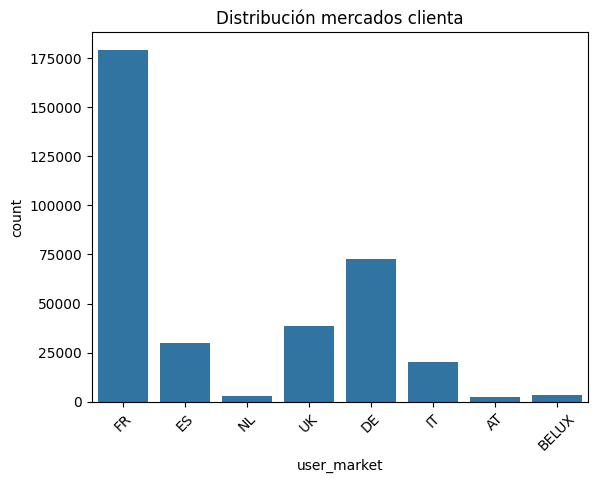

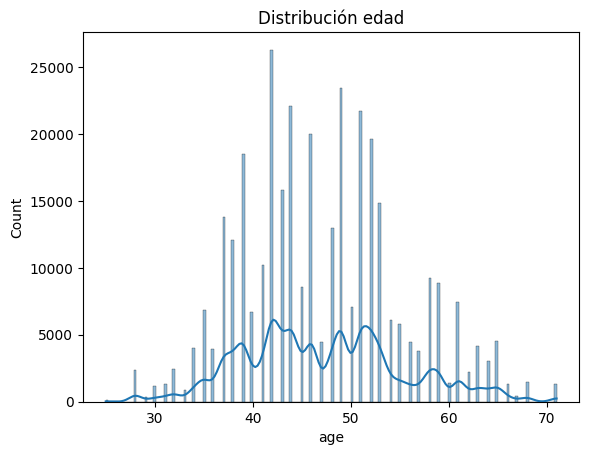

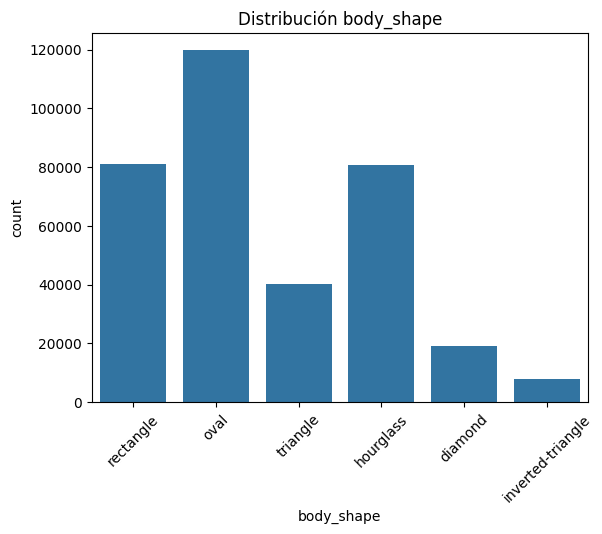

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Normalizar response
df["response"] = df["response"].astype(str).str.strip().isin(["True", "1", "true"])
df["response_int"] = df["response"].astype(int)

# Perfil demográfico / físico
client_cols = [
    "user_market", "frequency", "age", "height", "weight",
    "body_shape", "eyes", "hair", "job", "is_mother",
    "dress_leisure", "dress_work", "fit_top", "fit_bottom",
    "adventurous_x"
]

# Ejemplos: distribuciones
sns.countplot(data=df, x="user_market")
plt.xticks(rotation=45); plt.title("Distribución mercados clienta"); plt.show()

sns.histplot(data=df, x="age", kde=True)
plt.title("Distribución edad"); plt.show()

sns.countplot(data=df, x="body_shape")
plt.xticks(rotation=45); plt.title("Distribución body_shape"); plt.show()


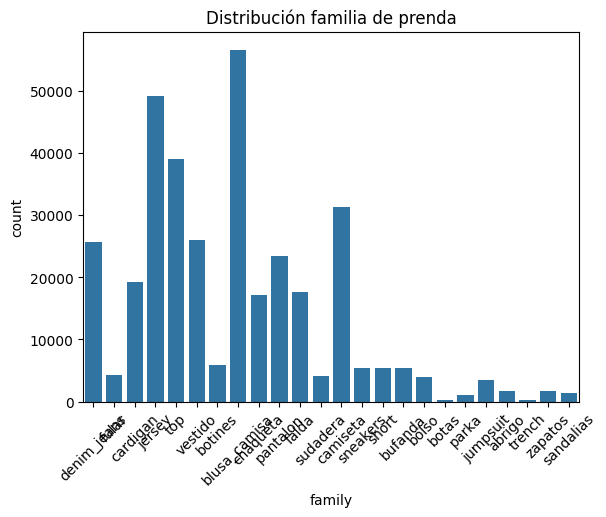

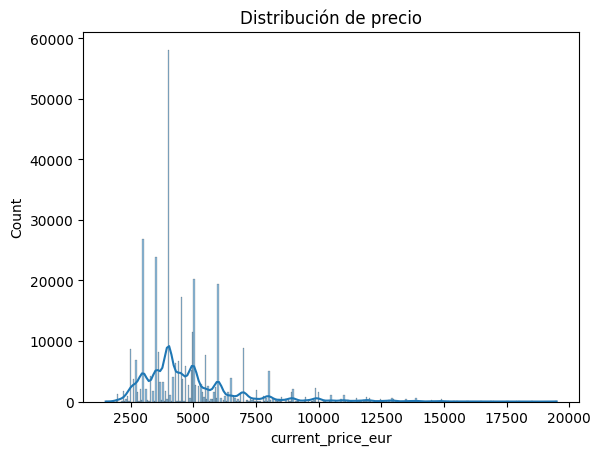

In [11]:
item_cols = [
    "season", "family", "brand", "color", "fit", "cut",
    "fabric", "print", "weather", "style_1", "style_2",
    "shot", "type_of_length", "current_price_eur"
]

sns.countplot(data=df, x="family")
plt.xticks(rotation=45); plt.title("Distribución familia de prenda"); plt.show()


sns.histplot(data=df, x="current_price_eur", kde=True)
plt.title("Distribución de precio"); plt.show()


In [12]:
valid_sizes = ['XS', 'S', 'M', 'L', 'XL']

for col in ['size_top', 'size_bottom']:
    df.loc[~df[col].isin(valid_sizes), col] = 'XL'


In [13]:
df['size'].unique()

array(['S', 'UNQ', 'M', 'L', 'X4XL', '39', 'XXXL', 'L-30', 'XS', 'XXL-28',
       'XXL', 'XL', 'X4XL-32', '40', 'XXL-30', 'L-32', 'M-30', '41', '37',
       '36', 'XS-30', 'XXL-32', 'XL-30', 'XXXL-32', 'S-32', '38', 'M-32',
       'XXS', 'S-30', 'XS-32', '42', 'XXXL-30', 'XL-32', 'M-34', 'M-28',
       'XS-34', 'L-28', 'L-34', 'XL-34', 'XXS-30', 'XXS-32', 'S-34', nan,
       'XXS-28', 'XS-28', 'XXXL-28', 'X4XL-30'], dtype=object)

In [14]:
import pandas as pd

df['chest_contour_q'] = pd.qcut(
    df_final['chest_contour'],
    q=5,            # quintiles
    duplicates='drop'  # por si hay muchos empates en los bordes
)


C:\Users\Martin\AppData\Local\Temp\ipykernel_3568\864596387.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['size_top', 'chest_contour_q'])['response_int']


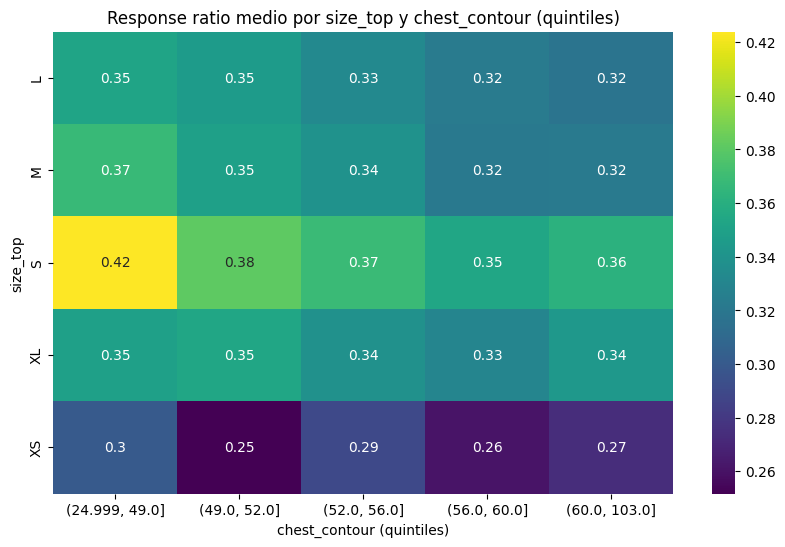

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

tabla = (
    df
    .groupby(['size_top', 'chest_contour_q'])['response_int']
    .mean()
    .reset_index()
)

matriz = tabla.pivot(
    index='size_top',
    columns='chest_contour_q',
    values='response_int'
)

plt.figure(figsize=(10,6))
sns.heatmap(matriz, annot=True, cmap='viridis')
plt.title('Response ratio medio por size_top y chest_contour (quintiles)')
plt.xlabel('chest_contour (quintiles)')
plt.ylabel('size_top')
plt.show()


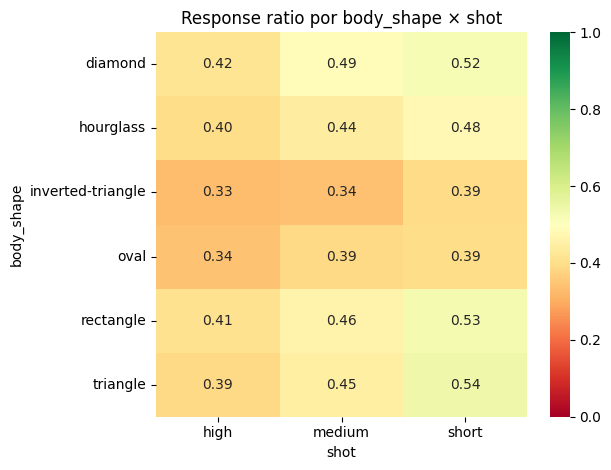

In [16]:
tmp = df[df["body_shape"].notna() & df["shot"].notna()].copy()

pivot = tmp.pivot_table(
    values="response_int",
    index="body_shape",
    columns="shot",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1)
plt.title("Response ratio por body_shape × shot")
plt.tight_layout()
plt.show()


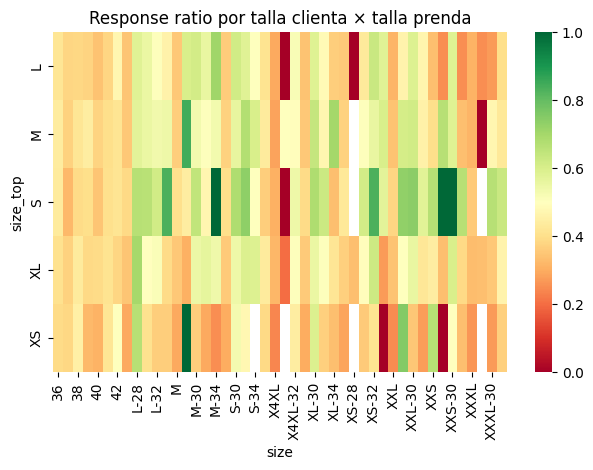

In [17]:
tmp = df[df["size_top"].notna() & df["size"].notna()].copy()

pivot = tmp.pivot_table(
    values="response_int",
    index="size_top",   # talla clienta
    columns="size",     # talla prenda
    aggfunc="mean"
)

sns.heatmap(pivot, annot=False, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1)
plt.title("Response ratio por talla clienta × talla prenda")
plt.tight_layout()
plt.show()


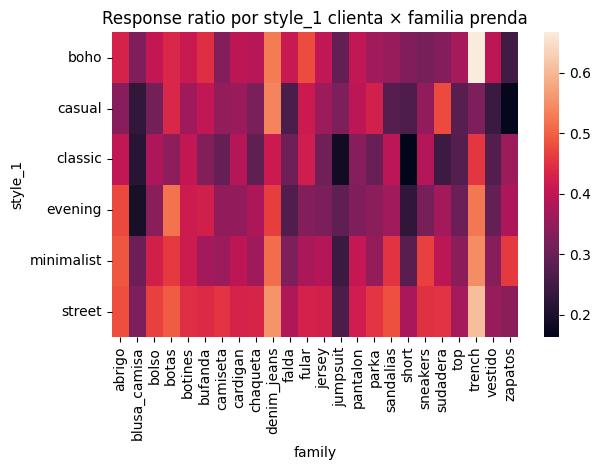

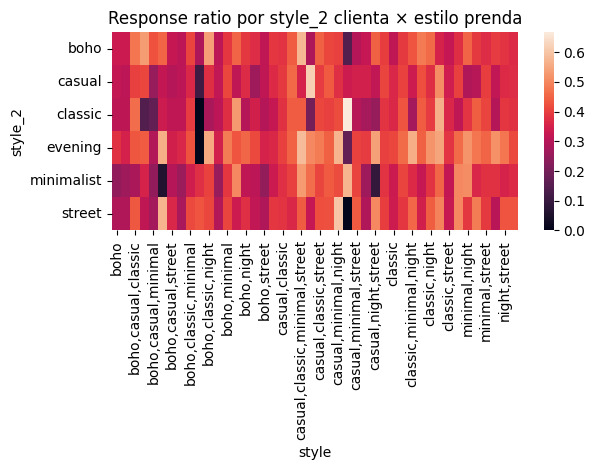

In [18]:
# style_1 clienta × family prenda
pivot = df.pivot_table(
    values="response_int",
    index="style_1",
    columns="family",
    aggfunc="mean"
)
sns.heatmap(pivot, annot=False, fmt=".2f")
plt.title("Response ratio por style_1 clienta × familia prenda")
plt.tight_layout()
plt.show()

# style_2 clienta × style (prenda)
pivot2 = df.pivot_table(
    values="response_int",
    index="style_2",
    columns="style",
    aggfunc="mean"
)
sns.heatmap(pivot2, annot=False, fmt=".2f")
plt.title("Response ratio por style_2 clienta × estilo prenda")
plt.tight_layout()
plt.show()


C:\Users\Martin\AppData\Local\Temp\ipykernel_3568\1123134923.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


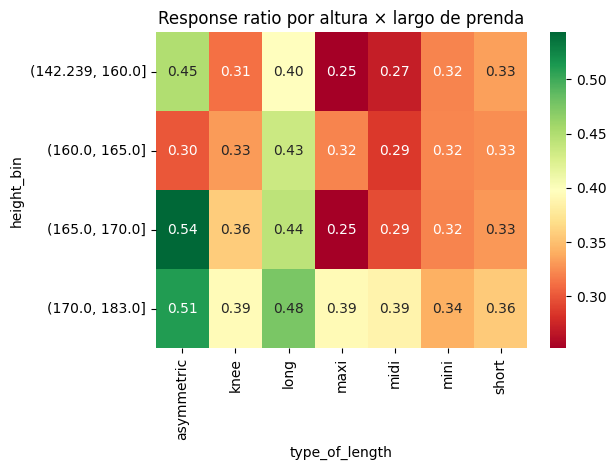

C:\Users\Martin\AppData\Local\Temp\ipykernel_3568\1123134923.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = df.pivot_table(


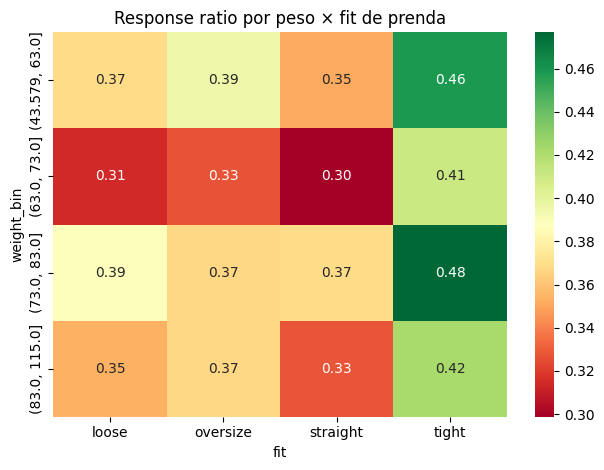

In [19]:
# Bins de altura / peso
df["height_bin"] = pd.qcut(df["height"], 4, duplicates="drop")
df["weight_bin"] = pd.qcut(df["weight"], 4, duplicates="drop")

# Altura × type_of_length
pivot = df.pivot_table(
    values="response_int",
    index="height_bin",
    columns="type_of_length",
    aggfunc="mean"
)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Response ratio por altura × largo de prenda")
plt.tight_layout()
plt.show()

# Peso × fit
pivot2 = df.pivot_table(
    values="response_int",
    index="weight_bin",
    columns="fit",
    aggfunc="mean"
)
sns.heatmap(pivot2, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Response ratio por peso × fit de prenda")
plt.tight_layout()
plt.show()
